In [3]:
import pandas as pd
df = pd.read_csv("cars.csv")
df.head(10)

C:\Users\Antônio Dias\AppData\Local\Temp\ipykernel_45332\4241761438.py:2: DtypeWarning: Columns (20: price) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("cars.csv")


,id,ref_code,maker,first_reg,listed_yr,listed_mo,odo,disp,gearbox,fuel,...,doors,seats,paint,power_bhp,econ_mpg,length_mm,annual_tax,entry_price,pct_of_list,price
0,A6796895,M1288,Bentley,2000.0,2018,4,60000,6.8L,Automatic,Petrol,...,4.0,5.0,Silver,NaN,NaN,5390.0,NaN,145000.0,0.1483,21500
1,A6544792,M1288,Bentley,2002.0,2018,6,44000,6.8L,Automatic,Petrol,...,4.0,5.0,Grey,450.0,13.7 mpg,5390.0,315,149000.0,0.1930,28750
2,A9945056,M1288,Bentley,2002.0,2017,11,55000,6.8L,Automatic,Petrol,...,4.0,5.0,Blue,400.0,14.7 mpg,5390.0,315,149000.0,0.2013,29999
3,A7702534,M1288,Bentley,2003.0,2018,4,14000,6.8L,Automatic,Petrol,...,4.0,5.0,Green,NaN,NaN,5390.0,NaN,151500.0,0.2307,34948
4,A1024660,M1288,Bentley,2003.0,2017,11,61652,6.8L,Automatic,Petrol,...,4.0,5.0,Grey,NaN,NaN,5390.0,NaN,151500.0,0.1753,26555
5,A6714845,M1288,Bentley,2002.0,2017,12,55000,6.8L,Automatic,Petrol,...,4.0,5.0,Blue,450.0,13.7 mpg,5390.0,315,149000.0,0.1674,24950
6,A5108990,M1288,Bentley,2002.0,2018,8,67000,6.8L,Automatic,Petrol,...,4.0,5.0,Green,450.0,13.7 mpg,5390.0,NaN,149000.0,0.2013,29995
7,A5499375,M1288,Bentley,2003.0,2018,4,99200,6.8L,Automatic,Petrol,...,4.0,5.0,Black,NaN,NaN,5390.0,NaN,151500.0,0.1482,22450
8,A7439592,M1288,Bentley,2003.0,2018,2,27541,6.8L,Automatic,Petrol,...,4.0,4.0,Silver,NaN,NaN,5390.0,NaN,151500.0,0.1782,26990
9,A4767271,M1288,Bentley,2003.0,2017,11,38000,6.8L,Automatic,Petrol,...,4.0,5.0,Silver,NaN,NaN,5390.0,NaN,151500.0,0.1980,29995


## Análise exploratória (superficial)

Visão geral da base: tamanho, tipos, valores faltantes, colunas que precisam de limpeza e distribuição dos dois alvos (`price` e `gearbox`).

In [4]:
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("cars.csv", low_memory=False)
print(df.shape)
df.info()

(170150, 21)
<class 'pandas.DataFrame'>
RangeIndex: 170150 entries, 0 to 170149
Data columns (total 21 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   id           170150 non-null  str    
 1   ref_code     170150 non-null  str    
 2   maker        170150 non-null  str    
 3   first_reg    170145 non-null  float64
 4   listed_yr    170150 non-null  int64  
 5   listed_mo    170150 non-null  int64  
 6   odo          169472 non-null  str    
 7   disp         169011 non-null  str    
 8   gearbox      170033 non-null  str    
 9   fuel         169800 non-null  str    
 10  body         169440 non-null  str    
 11  doors        166646 non-null  float64
 12  seats        165319 non-null  float64
 13  paint        150865 non-null  str    
 14  power_bhp    148271 non-null  float64
 15  econ_mpg     141809 non-null  str    
 16  length_mm    152138 non-null  float64
 17  annual_tax   139864 non-null  str    
 18  entry_price  144352 no

### Valores faltantes

In [5]:
faltantes = df.isna().mean().sort_values(ascending=False)
faltantes[faltantes > 0].mul(100).round(1).to_frame("% faltante")

,% faltante
annual_tax,17.8
econ_mpg,16.7
pct_of_list,15.4
entry_price,15.2
power_bhp,12.9
paint,11.3
length_mm,10.6
seats,2.8
doors,2.1
disp,0.7


### Colunas numéricas guardadas como texto

`price`, `odo`, `disp`, `econ_mpg` e `annual_tax` vêm como texto (sufixos como `L`, `mpg`, `mile(s)`, `*`, ou o valor `"Uknown"` em `price`). Abaixo, os valores que não viram número diretamente.

In [6]:
for col in ["price", "odo", "disp", "econ_mpg", "annual_tax"]:
    s = df[col].dropna().astype(str)
    nao_num = s[pd.to_numeric(s, errors="coerce").isna()]
    print(f"{col}: {len(nao_num)} valores não numéricos | exemplos: {nao_num.value_counts().head(5).to_dict()}")

price: 914 valores não numéricos | exemplos: {'Uknown': 914}
odo: 207 valores não numéricos | exemplos: {'1 mile': 207}
disp: 169011 valores não numéricos | exemplos: {'2.0L': 40908, '1.6L': 26332, '3.0L': 15174, '1.2L': 13350, '1.4L': 12784}
econ_mpg: 141809 valores não numéricos | exemplos: {'47.1 mpg': 5511, '62.8 mpg': 5495, '55.4 mpg': 5258, '47.9 mpg': 5072, '54.3 mpg': 4511}
annual_tax: 21719 valores não numéricos | exemplos: {' 140*': 20063, ' 130*': 1126, '*': 401, ' 0*': 129}


In [7]:
# Conversão rápida só para a exploração (a limpeza definitiva fica para o pipeline)
eda = df.copy()
eda["price"] = pd.to_numeric(eda["price"], errors="coerce")
eda["odo"] = pd.to_numeric(eda["odo"].astype(str).str.replace(r"[^\d.]", "", regex=True), errors="coerce")
eda["disp"] = pd.to_numeric(eda["disp"].str.rstrip("L"), errors="coerce")
eda["econ_mpg"] = pd.to_numeric(eda["econ_mpg"].str.replace("mpg", ""), errors="coerce")
eda["annual_tax"] = pd.to_numeric(eda["annual_tax"].str.replace("*", "", regex=False), errors="coerce")
eda["idade"] = eda["listed_yr"] - eda["first_reg"]

eda.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
first_reg,170145.0,2012.69,4.50,1900.00,2010.00,2014.00,2016.00,2019.00
listed_yr,170150.0,2018.12,0.74,2012.00,2018.00,2018.00,2018.00,2021.00
listed_mo,170150.0,5.61,2.08,1.00,4.00,5.00,7.00,17.00
odo,169472.0,48182.55,42992.03,0.00,14354.00,39117.00,74600.00,6363342.00
disp,169011.0,11.56,145.66,0.30,1.40,1.80,2.00,6900.00
doors,166646.0,4.36,1.02,0.00,4.00,5.00,5.00,7.00
seats,165319.0,4.89,0.86,1.00,5.00,5.00,5.00,17.00
power_bhp,148271.0,148.19,80.85,17.00,99.00,128.00,171.00,740.00
econ_mpg,141809.0,51.26,13.42,9.80,42.20,50.40,60.10,200.00
length_mm,152138.0,4366.60,420.18,0.00,4083.00,4387.00,4672.00,6165.00


### Variáveis categóricas

In [8]:
cat_cols = ["maker", "ref_code", "gearbox", "fuel", "body", "paint"]
eda[cat_cols].nunique().to_frame("categorias distintas")

,categorias distintas
maker,88
ref_code,513
gearbox,3
fuel,13
body,18
paint,22


In [10]:
for col in ["gearbox", "fuel", "body"]:
    print(eda[col].value_counts(dropna=False), "")

gearbox
Manual            108838
Automatic          61085
NaN                  117
Semi-Automatic       110
Name: count, dtype: int64 
fuel
Diesel                             83053
Petrol                             81148
Hybrid  Petrol/Electric             3767
Electric                             703
Hybrid  Petrol/Electric Plug-in      462
NaN                                  350
Petrol Hybrid                        298
Petrol Plug-in Hybrid                185
Hybrid  Diesel/Electric               81
Diesel Hybrid                         34
Hybrid  Diesel/Electric Plug-in       34
Bi Fuel                               25
Petrol Ethanol                         8
Diesel Plug-in Hybrid                  2
Name: count, dtype: int64 
body
Hatchback          67035
SUV                39354
Saloon             14542
MPV                13775
Estate             11533
Coupe              10901
Convertible         8846
Pickup              2455
NaN                  710
Combi Van            450
Pane

In [11]:
eda["maker"].value_counts().head(15)

maker
Ford             21045
Audi             14296
Vauxhall         13577
BMW              12080
Volkswagen       11917
Toyota            8013
Peugeot           7112
Nissan            6098
Mazda             5463
Jaguar            5137
Mercedes-Benz     5015
Kia               4999
Renault           4984
SKODA             4568
Volvo             4519
Name: count, dtype: int64

### Alvo 1: `price`

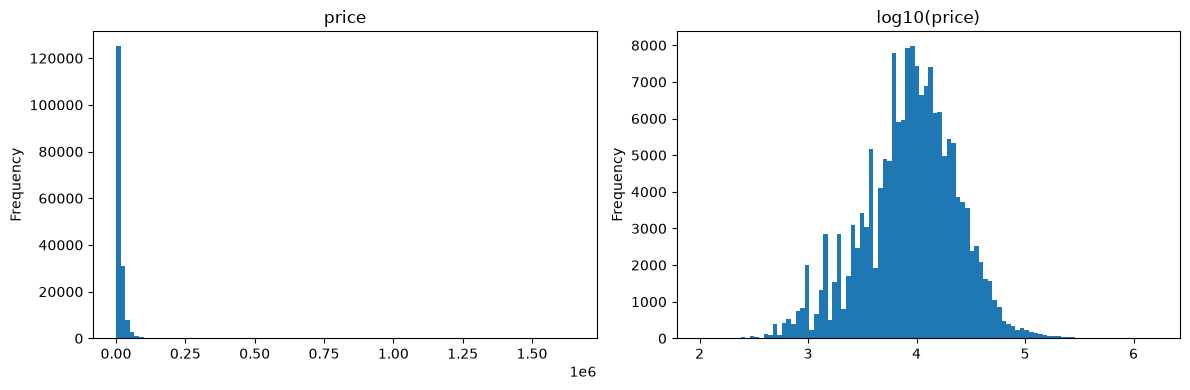

count     169236.0
mean       14104.0
std        20662.0
min          100.0
1%           695.0
25%         4990.0
50%         9395.0
75%        16995.0
99%        79950.0
max      1650000.0
Name: price, dtype: float64

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
eda["price"].plot.hist(bins=100, ax=axes[0], title="price")
np.log10(eda["price"]).plot.hist(bins=100, ax=axes[1], title="log10(price)")
plt.tight_layout()
plt.show()

eda["price"].describe(percentiles=[.01, .25, .5, .75, .99]).round(0)

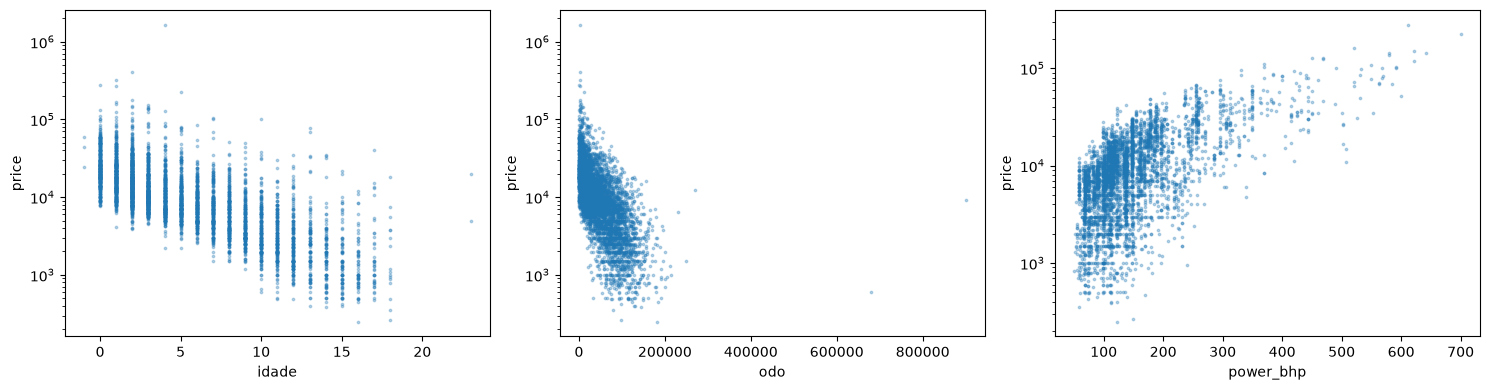

idade         -0.343933
odo           -0.328904
econ_mpg      -0.166858
doors         -0.152275
seats         -0.125222
listed_mo     -0.038701
disp           0.018878
listed_yr      0.101949
annual_tax     0.185979
length_mm      0.333384
first_reg      0.346075
pct_of_list    0.599356
power_bhp      0.695483
entry_price    0.796869
Name: price, dtype: float64

In [13]:
# Relação do preço com algumas numéricas (amostra para o gráfico ficar leve)
amostra = eda.sample(5000, random_state=0)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["idade", "odo", "power_bhp"]):
    ax.scatter(amostra[col], amostra["price"], s=3, alpha=0.3)
    ax.set_yscale("log")
    ax.set_xlabel(col)
    ax.set_ylabel("price")
plt.tight_layout()
plt.show()

eda.select_dtypes("number").corr()["price"].drop("price").sort_values()

### Alvo 2: `gearbox`

In [15]:
print(eda["gearbox"].value_counts(normalize=True).round(3))

# Proporção de automáticos por algumas categorias
for col in ["fuel", "body"]:
    tab = (eda.assign(auto=eda["gearbox"].eq("Automatic"))
              .groupby(col)["auto"].agg(["mean", "size"])
              .query("size >= 100").sort_values("mean", ascending=False))
    print(tab.round(3), "")

gearbox
Manual            0.640
Automatic         0.359
Semi-Automatic    0.001
Name: proportion, dtype: float64
                                  mean   size
fuel                                         
Hybrid  Petrol/Electric Plug-in  1.000    462
Petrol Plug-in Hybrid            1.000    185
Electric                         0.994    703
Petrol Hybrid                    0.990    298
Hybrid  Petrol/Electric          0.967   3767
Diesel                           0.411  83053
Petrol                           0.262  81148 
              mean   size
body                     
Panel Van    0.769    221
Saloon       0.640  14542
Coupe        0.586  10901
SUV          0.501  39354
Estate       0.416  11533
Convertible  0.395   8846
Pickup       0.349   2455
MPV          0.293  13775
Combi Van    0.209    450
Hatchback    0.177  67035 


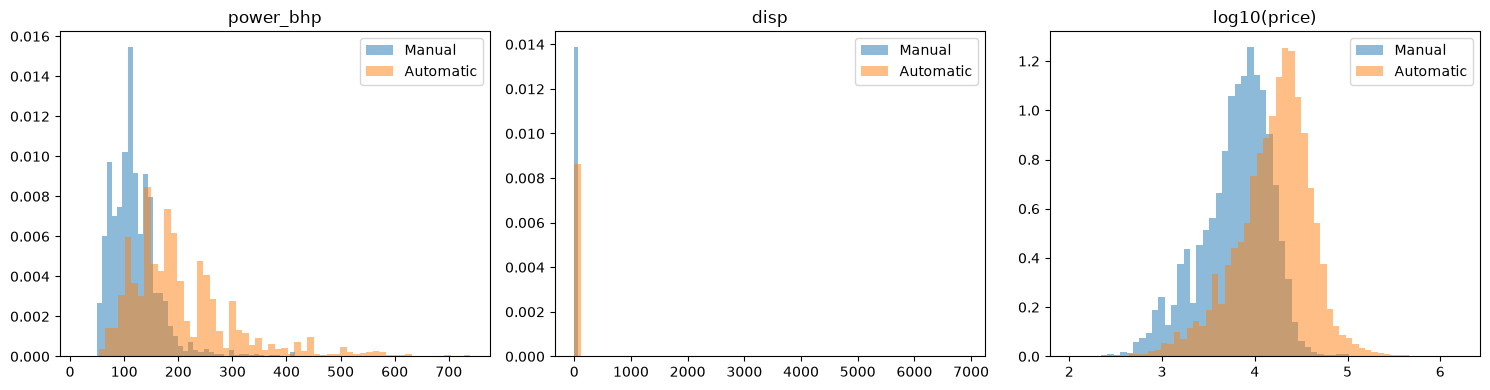

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["power_bhp", "disp", "price"]):
    for g in ["Manual", "Automatic"]:
        vals = eda.loc[eda["gearbox"] == g, col].dropna()
        if col == "price":
            vals = np.log10(vals)
        ax.hist(vals, bins=60, alpha=0.5, density=True, label=g)
    ax.set_title(col if col != "price" else "log10(price)")
    ax.legend()
plt.tight_layout()
plt.show()

### Primeiras observações

- **170 mil anúncios, 21 colunas.** Várias colunas numéricas estão como texto (`price`, `odo`, `disp`, `econ_mpg`, `annual_tax`) e precisam de limpeza.
- **`price` tem 914 valores `"Uknown"`** — essas linhas não servem para treinar o modelo de preço. A distribuição é bem assimétrica; `log(price)` fica muito mais comportada.
- **`pct_of_list` = `price / entry_price`**: usa o próprio alvo, então é **vazamento** e não pode entrar no modelo de preço (nem estará disponível num anúncio novo).
- **`gearbox`**: ~64% Manual, ~36% Automatic, e só 110 `Semi-Automatic` (decidir se descarta ou agrupa). Potência, cilindrada e preço separam bem as classes.
- **Faltantes** de até ~18% em `annual_tax`, `econ_mpg`, `entry_price`, `power_bhp`, `length_mm` e `paint`.
- **Anomalias**: `listed_mo` tem um valor 17; `body` tem 5 linhas `"Manual"`; `fuel` tem variações de escrita do mesmo tipo (ex.: `Hybrid  Petrol/Electric` vs `Petrol Hybrid`); `odo` tem valores como `"1 mile"`.
- **Alta cardinalidade**: `ref_code` (513) e `maker` (88) exigem cuidado na codificação, especialmente porque o conjunto de avaliação tem composição diferente.